In [10]:
import pandas as pd
import os 
import jieba
import re
import matplotlib.pyplot as plt
import numpy as np

In [23]:
file_name = 'similarity_record_2025邁向新世代前瞻人工智慧研究專案_合併版_推薦表統合_VBA.xlsx'
file_path = os.path.join(os.path.abspath("../data/output/"),file_name)
# 1. 最簡單的讀取方式
df = pd.read_excel(file_path)
data_dict = df.to_dict(orient='records')
analysis_datas = {}
for data in data_dict:
    if data['recommended_manager'] not in analysis_datas:
        analysis_datas[data['recommended_manager']] = [data]
    else:
        analysis_datas[data['recommended_manager']].append(data)
print(analysis_datas)

{'李建樹': [{'query_text': '可信賴的生成式虛擬三維組織病理學 組織病理學、生成式人工智慧、深度學習、生物醫學影像 三維虛擬組織病理學是醫學影像和診斷領域一項令人振奮的新興領域。它無需手術切片，透過高解析度灰階光學影像，生成類似傳統的組織病理學影像，以輔助醫師診斷。 鑑於本團隊在二維光學同調斷層掃描影像到H&E影像生成方面取得的國際領先成果，本計劃擬將其擴展到三維H&E 影像生成。此外，近年多種生物醫學影像技術在細胞解析度方面取得了快速發展，每種成像技術都能提取一些生物醫學特徵和特性，經由國際合作整合這些組織結構和成分之生物資訊，可以大幅推進生成的H&E 影像的可信任性。以臨床三維高解析度光學影像實現三維虛擬切片，可以使得個人化治療計劃中與放射組學、基因組學和數位孿生有更深層的結合。 本計畫擬分四年執行，第一年，除了二維細胞核及組織結構之外，將使用H&E 影像做半監督學習，增加色素性及功能性細胞之分割，我們也將實作一種參考引導降噪演算法來提升三維影像品質；第二年，將發展一種交叉引用的註釋方法，以精確分割三維細胞核邊界，並將採用標籤輔助的二維組織結構和成分轉換；第三年，將透過整合多樣化的生物醫學影像來實現三維生成式H&E 影像，並結合主動學習方法，以減少註釋需求；第四年，我們將嘗試解釋並分析模型推論結果，實現可信賴的三維虛擬組織病理學。', 'compared_text': '利用深層類神經網路與生成對抗網路進行乳房腫瘤病理切片影像分析之研究 本研究針對乳房組織切片影像分析規劃一個三年期計畫，第一年的研究重點為乳房組織切片影像前處理，欲發展的技術包括：組織切片褶疊區域分割、組織切片染色色彩變異校正；第二年的研究重點為細胞核導向式分類技術開發，預計發展的技術包括：細胞核分割、細胞核特徵擷取、良性與惡性腫瘤分類。第三年的研究重點為全域導向式分類技術開發，欲發展的技術包括：整合bilinear CNN model至GAN分類架構，分類組織切片影像的良性與惡性腫瘤種類。 乳房組織切片影像、褶疊區域、細胞核分割、腫瘤\n\n植基於光流與監督式對比學習之加護病房病患臉部疼痛表情等級估測之研究 有鑑於目前加護病房亟需能自動估測病患疼痛等級的系統提供協助，以隨時掌握病患的疼痛狀況，本研究以此為目標進行系統規劃，先藉由定位未受遮蔽的眼額區域，彙整區域光流資訊，再透過

In [5]:
recommand_count = {}
for data in analysis_datas.keys():
    recommand_count[data] = len(analysis_datas[data])
print(recommand_count)

{'李建樹': 5, '鄭昌杰': 2, '張財榮': 3, '郭景明': 15, '蕭邱漢': 4, '黃耀賢': 4, '鍾國亮': 1, '李元綺': 3, '黃育仁': 1, '陳敦裕': 1, '賴飛羆': 16, '吳經閔': 10, '盧文祥': 11, '陳宜欣': 8, '羅友聲': 11, '古倫維': 36, '薛幼苓': 6, '林佩蓉': 3, '顏志達': 10, '白敦文': 6, '劉吉軒': 26, '李健興': 7, '林金玲': 15, '傅楸善': 16, '楊家輝': 5, '吳宗憲': 11, '黃詰琳': 14, '林智揚': 19, '黃建宏': 7, '蔡佩倩': 3, '李俊宏': 8, '詹毓偉': 2, '李素玲': 1, '邱志義': 1, '陳以錚': 1, '徐讚昇': 1, '楊烽正': 12, '夏世昌': 8, '曹昱': 5, '曾新穆': 3, '陳錫明': 1, '簡仁宗': 3, '方瓊瑤': 5, '王駿發': 9, '陳祝嵩': 2, '吳志宏': 6, '陳仁暉': 2, '鍾翊方': 1, '連琬菁': 6, '余松年': 8, '李錫智': 2, '賴文能': 4, '范端芳': 5, '張意政': 2, '林佩君': 1, '周賢興': 10, '羅惟正': 2, '王元凱': 3, '林泓宏': 8, '陳朝鈞': 5, '莊坤達': 2, '李思慧': 9, '吳政瑋': 8, '黃士嘉': 7, '黃登淵': 5, '林澤': 5, '烏斯馬': 1, '阮雪芬': 1, '楊正宏': 1, '吳育瑋': 1, '蘇家玉': 1, '洪炯宗': 1, '張資昊': 2, '郭耀煌': 5, '賴冠廷': 5, '龔旭陽': 2, '陳政宏': 1, '黃敬群': 2, '邱維辰': 1, '陳嘉平': 3, '楊致芳': 1, '陳彥霖': 1, '李偉柏': 5, '蔡英德': 3, '李琳山': 5, '唐傳義': 1, '江政欽': 3, '蘇明祥': 1, '蔡佳芬': 1, '葉瑞峰': 2, '黃世強': 2, '王豐緒': 1, '吳世弘': 2, '范耀中': 3, '陸子強': 2, '雷伯瑞': 2, '李宗南': 2, '吳賦哲': 1, '徐建業':

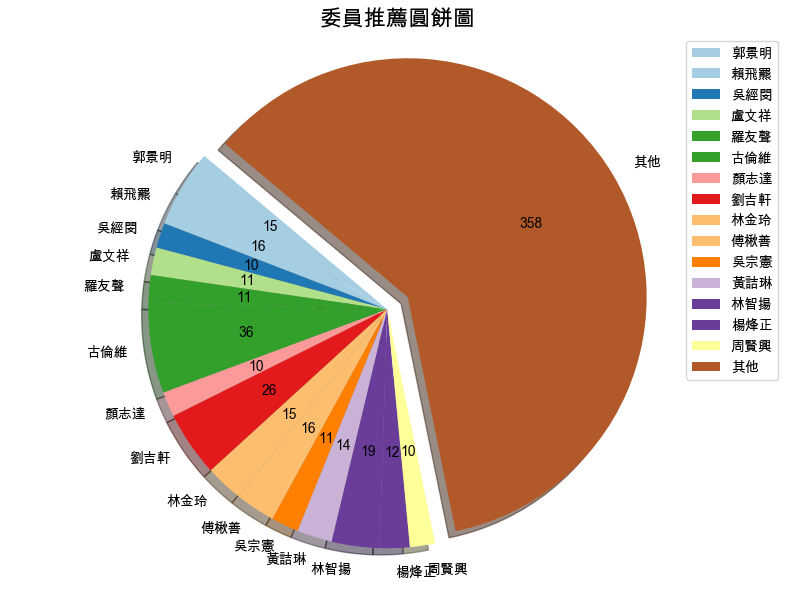

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# 使用更通用的字體設置
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans', 'Bitstream Vera Sans', 'sans-serif']
mpl.rcParams['axes.unicode_minus'] = False

# 合併小類別
threshold = 10
other_sum = 0
new_recommand_count = {}

for label, size in recommand_count.items():
    if size < threshold:
        other_sum += size
    else:
        new_recommand_count[label] = size

if other_sum > 0:
    new_recommand_count['其他'] = other_sum

# 提取新的標籤和數值
labels = list(new_recommand_count.keys())
sizes = list(new_recommand_count.values())
colors = plt.cm.Paired(np.arange(len(new_recommand_count)) / len(new_recommand_count))

explode = [0] * len(new_recommand_count)
max_index = sizes.index(max(sizes))
explode[max_index] = 0.1

# 自定義函數，只顯示數值
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{:d}'.format(val)
    return my_format

plt.figure(figsize=(10, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct=autopct_format(sizes), shadow=True, startangle=140)
plt.axis('equal')

plt.title('委員推薦圓餅圖', fontsize=16)
plt.legend(labels, loc="best")

plt.show()


In [ ]:
common_words = []
def analyze_similarity(text1, text2):
    words1 = set(jieba.cut(text1))
    words2 = set(jieba.cut(text2))
    
    common = words1.intersection(words2)
    diff1 = words1 - words2
    diff2 = words2 - words1
    
    # print(f"共同關鍵詞: {common}")
    # print(f"Query 獨有詞: {diff1}")
    # print(f"結果 獨有詞: {diff2}")
    common_words.append(list(common))

for data in data_dict:
    analyze_similarity(data['query_text'],data['compared_text'])
print(common_words)

Building prefix dict from the default dictionary ...


{'query_text': '可信賴的生成式虛擬三維組織病理學 組織病理學、生成式人工智慧、深度學習、生物醫學影像 三維虛擬組織病理學是醫學影像和診斷領域一項令人振奮的新興領域。它無需手術切片，透過高解析度灰階光學影像，生成類似傳統的組織病理學影像，以輔助醫師診斷。 鑑於本團隊在二維光學同調斷層掃描影像到H&E影像生成方面取得的國際領先成果，本計劃擬將其擴展到三維H&E 影像生成。此外，近年多種生物醫學影像技術在細胞解析度方面取得了快速發展，每種成像技術都能提取一些生物醫學特徵和特性，經由國際合作整合這些組織結構和成分之生物資訊，可以大幅推進生成的H&E 影像的可信任性。以臨床三維高解析度光學影像實現三維虛擬切片，可以使得個人化治療計劃中與放射組學、基因組學和數位孿生有更深層的結合。 本計畫擬分四年執行，第一年，除了二維細胞核及組織結構之外，將使用H&E 影像做半監督學習，增加色素性及功能性細胞之分割，我們也將實作一種參考引導降噪演算法來提升三維影像品質；第二年，將發展一種交叉引用的註釋方法，以精確分割三維細胞核邊界，並將採用標籤輔助的二維組織結構和成分轉換；第三年，將透過整合多樣化的生物醫學影像來實現三維生成式H&E 影像，並結合主動學習方法，以減少註釋需求；第四年，我們將嘗試解釋並分析模型推論結果，實現可信賴的三維虛擬組織病理學。', 'compared_text': '利用深層類神經網路與生成對抗網路進行乳房腫瘤病理切片影像分析之研究 本研究針對乳房組織切片影像分析規劃一個三年期計畫，第一年的研究重點為乳房組織切片影像前處理，欲發展的技術包括：組織切片褶疊區域分割、組織切片染色色彩變異校正；第二年的研究重點為細胞核導向式分類技術開發，預計發展的技術包括：細胞核分割、細胞核特徵擷取、良性與惡性腫瘤分類。第三年的研究重點為全域導向式分類技術開發，欲發展的技術包括：整合bilinear CNN model至GAN分類架構，分類組織切片影像的良性與惡性腫瘤種類。 乳房組織切片影像、褶疊區域、細胞核分割、腫瘤\n\n植基於光流與監督式對比學習之加護病房病患臉部疼痛表情等級估測之研究 有鑑於目前加護病房亟需能自動估測病患疼痛等級的系統提供協助，以隨時掌握病患的疼痛狀況，本研究以此為目標進行系統規劃，先藉由定位未受遮蔽的眼額區域，彙整區域光流資訊，再透過轉移學習機制與監督

Dumping model to file cache /var/folders/fp/dtn327ps5sbd8kv55hgt09g00000gp/T/jieba.cache
Loading model cost 0.434 seconds.
Prefix dict has been built successfully.


{'query_text': '可信賴的生成式虛擬三維組織病理學 組織病理學、生成式人工智慧、深度學習、生物醫學影像 三維虛擬組織病理學是醫學影像和診斷領域一項令人振奮的新興領域。它無需手術切片，透過高解析度灰階光學影像，生成類似傳統的組織病理學影像，以輔助醫師診斷。 鑑於本團隊在二維光學同調斷層掃描影像到H&E影像生成方面取得的國際領先成果，本計劃擬將其擴展到三維H&E 影像生成。此外，近年多種生物醫學影像技術在細胞解析度方面取得了快速發展，每種成像技術都能提取一些生物醫學特徵和特性，經由國際合作整合這些組織結構和成分之生物資訊，可以大幅推進生成的H&E 影像的可信任性。以臨床三維高解析度光學影像實現三維虛擬切片，可以使得個人化治療計劃中與放射組學、基因組學和數位孿生有更深層的結合。 本計畫擬分四年執行，第一年，除了二維細胞核及組織結構之外，將使用H&E 影像做半監督學習，增加色素性及功能性細胞之分割，我們也將實作一種參考引導降噪演算法來提升三維影像品質；第二年，將發展一種交叉引用的註釋方法，以精確分割三維細胞核邊界，並將採用標籤輔助的二維組織結構和成分轉換；第三年，將透過整合多樣化的生物醫學影像來實現三維生成式H&E 影像，並結合主動學習方法，以減少註釋需求；第四年，我們將嘗試解釋並分析模型推論結果，實現可信賴的三維虛擬組織病理學。', 'compared_text': '開發低劑量三維電腦斷層影像的重建演算法、誤差校正法以及網頁式視覺化系統 本計劃有三大研究主題。第一個主題是開發出有效率的演算法將低劑量的X光投影重建出三維斷層(3DCT)影像，希望能從少量的X光投影重建出高品質的3DCT影像。第二個主題是設計誤差校正法來解決低劑量3DCT掃描的兩種誤差，分別為掃描軌跡偏差與X光感測器誤差。第三個主題是設計出一個網頁式的遠端視覺化系統，並搭配IoT技術，讓使用者可在任何的網際網路存取裝置(包含智慧型行動裝置)觀看並分析大量的三維斷層影像。本計畫是三年計畫，將逐年完成這三個研究主題。 三維電腦斷層影像、低劑量電腦斷層影像、有限投影角度、掃描軌跡偏差、感測器誤差、深度學習、類神經網路、生成對抗網路、網頁視覺化系統、物聯網\n\n橢圓組合於影像抽象、多媒體應用與電腦斷層影像重建 本計畫分為三個階段。在第一階段中，我們將提出一個新的影像抽象法。主要概念是將一組不同位置、

In [27]:
flat_common_words = [word for sublist in common_words for word in sublist]
cleaned_words = [w for w in flat_common_words if re.match(r'^\w+$', w) and len(w)>1]
print(cleaned_words)

['提升', '生成', '第一年', '細胞', '整合', '第二年', '透過', '學習', '資訊', '第三年', '發展', '分割', '技術', '組織', '影像', '臨床', '切片', '生成', '第一年', '一種', '本計畫', '第二年', '我們', '學習', '可以', '二維', '本計劃', '掃描', '深度', '技術', '使得', '演算法', '方法', '影像', '計劃', '生成', '第一年', '轉換', '領域', '人工智慧', '結果', '本計畫', '近年', '第二年', '使用', '除了', '透過', '學習', '可以', '第三年', '掃描', '放射', '深度', '治療', '醫學', '分割', '技術', '醫師', '組織', '方法', '影像', '結構', '類似', '診斷', '切片', '生成', '一種', '轉換', '領域', '人工智慧', '特性', '本計畫', '傳統', '整合', '使用', '組學', '病理', '透過', '學習', '擴展', '資訊', '取得', '需求', '監督學習', '以輔助', '品質', '此外', '放射', '深度', '發展', '醫學', '技術', '結合', '醫師', '輔助', '組織', '實現', '演算法', '方法', '影像', '臨床', '數位', '診斷', '提升', '成果', '人工智慧', '增加', '本計畫', '精確', '使用', '透過', '學習', '資訊', '合作', '品質', '深度', '發展', '分割', '技術', '結合', '醫師', '輔助', '演算法', '影像', '臨床', '診斷', '快速', '提升', '生成', '第一年', '成果', '一種', '領域', '增加', '結果', '近年', '第二年', '使用', '透過', '國際', '學習', '資訊', '取得', '掃描', '深度', '醫學', '發展', '技術', '使得', '醫師', '輔助', '組織', '方法', '影像', '快速', '計劃', '提升', '第一年', '成果', '一種', '並將', '結果',

In [28]:
from collections import Counter

# 統計出現次數
word_counts = Counter(cleaned_words)
# 顯示前 10 名最相關的關鍵詞
for word, count in word_counts.most_common():
    print(f"{word}: {count} 次")


應用: 431 次
技術: 421 次
模型: 395 次
系統: 368 次
學習: 354 次
本計畫: 354 次
整合: 307 次
研究: 303 次
發展: 288 次
智慧: 260 次
資料: 244 次
計畫: 238 次
人工智慧: 231 次
進行: 210 次
開發: 203 次
透過: 198 次
AI: 198 次
深度: 193 次
目標: 177 次
能力: 163 次
分析: 153 次
醫療: 152 次
建立: 138 次
環境: 133 次
平台: 122 次
提升: 119 次
結合: 118 次
核心: 116 次
臨床: 113 次
建構: 113 次
架構: 110 次
提供: 110 次
語言: 109 次
領域: 105 次
實現: 105 次
設計: 104 次
訓練: 102 次
基礎: 101 次
提出: 101 次
影像: 100 次
問題: 91 次
機制: 89 次
一個: 88 次
生成: 82 次
使用: 82 次
演算法: 81 次
預測: 78 次
機器: 77 次
照護: 76 次
解決: 75 次
處理: 71 次
強化: 70 次
關鍵: 70 次
本計: 70 次
同時: 70 次
我們: 69 次
以及: 69 次
決策: 68 次
方法: 67 次
完成: 67 次
偵測: 65 次
診斷: 61 次
自主: 61 次
健康: 60 次
需求: 59 次
合作: 57 次
模組: 57 次
快速: 56 次
輔助: 55 次
有效: 55 次
任務: 54 次
包含: 54 次
互動: 54 次
資訊: 52 次
神經: 52 次
台灣: 52 次
安全: 51 次
執行: 51 次
不同: 51 次
研發: 50 次
評估: 50 次
網路: 49 次
具有: 49 次
驗證: 48 次
理解: 48 次
一套: 48 次
醫學: 47 次
精準: 47 次
數位: 46 次
自動: 46 次
畫將: 46 次
疾病: 45 次
規劃: 45 次
視覺: 45 次
控制: 45 次
科技: 43 次
挑戰: 42 次
然而: 42 次
第二年: 41 次
創新: 41 次
辨識: 41 次
場域: 39 次
策略: 39 次
計算: 38 次
國際: 37 次
運算: 37 次
包

In [ ]:
import pandas as pd
import os

file_name = '(勿對外公開資料或流傳)108-112年智慧計算學門大批專題計畫申請案件(含中英文摘要及關鍵字)1130215.xlsx'
file_path = os.path.join(os.path.abspath("../data/research_proj/"), file_name)

# 要保留的欄位
columns_to_keep = ['計畫中文名稱', '中文摘要', '中文關鍵字']

# 讀取所有分頁
all_sheets = pd.read_excel(file_path, sheet_name=None)

# 用於存儲所有分頁的結果
all_data = []

# 處理每個分頁
for sheet_name, df in all_sheets.items():
    print(f"處理分頁: {sheet_name}")
    
    # 檢查分頁是否包含所需的欄位
    missing_columns = [col for col in columns_to_keep if col not in df.columns]
    if missing_columns:
        print(f"  警告: 分頁 '{sheet_name}' 缺少以下欄位: {missing_columns}")
        print(f"  可用的欄位: {df.columns.tolist()}")
        continue
    
    # 只保留需要的欄位
    df_filtered = df[columns_to_keep]
    
    # 轉換為字典列表
    data_dict = df_filtered.to_dict(orient='records')
    
    # 添加到總結果中
    all_data.extend(data_dict)
    
    print(f"  已處理 {len(data_dict)} 筆資料")

print(f"\n總共收集了 {len(all_data)} 筆資料")

處理分頁: 113-114
  已處理 319 筆資料
處理分頁: 112
  已處理 605 筆資料
處理分頁: 111
  已處理 581 筆資料
處理分頁: 110
  已處理 609 筆資料
處理分頁: 109
  已處理 578 筆資料
處理分頁: 108
  已處理 572 筆資料

總共收集了 3264 筆資料

資料範例:
記錄 1:
  計畫中文名稱: 子計畫二：基於零知識強化學習技術之精確證明問題研究
  中文摘要: nan
  中文關鍵字: nan
  來源分頁: 113-114

記錄 2:
  計畫中文名稱: 子計畫三：生成式視訊編輯與相關電腦視覺技術
  中文摘要: nan
  中文關鍵字: nan
  來源分頁: 113-114

記錄 3:
  計畫中文名稱: 發展用於理解非結構化金融數據及其應用的檢索式語言模型
  中文摘要: nan
  中文關鍵字: nan
  來源分頁: 113-114



In [43]:
print(all_data[0])
name = []
summary = []
keywords = []
for data in all_data:
    name.append(data['計畫中文名稱'])
    summary.append(data['中文摘要'])
    keywords.append(data['中文關鍵字'])

{'計畫中文名稱': '子計畫二：基於零知識強化學習技術之精確證明問題研究', '中文摘要': nan, '中文關鍵字': nan, '來源分頁': '113-114'}


In [44]:
import pandas as pd
import numpy as np
import jieba
import jieba.analyse
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 創建DataFrame以方便分析
df = pd.DataFrame({
    '計畫中文名稱': name,
    '中文摘要': summary,
    '中文關鍵字': keywords
})

# 顯示基本統計信息
print(f"總計畫數量: {len(df)}")
print(f"計畫名稱平均長度: {df['計畫中文名稱'].str.len().mean():.2f} 字元")
print(f"中文摘要平均長度: {df['中文摘要'].str.len().mean():.2f} 字元")
print(f"中文關鍵字平均長度: {df['中文關鍵字'].str.len().mean():.2f} 字元")

# 分析常見詞彙（以摘要為例）
all_words = []
for text in df['中文摘要'].dropna():
    words = jieba.lcut(text)
    all_words.extend(words)

word_count = Counter(all_words)
print("\n摘要中最常見的20個詞:")
print(word_count.most_common(20))

總計畫數量: 3264
計畫名稱平均長度: 25.22 字元
中文摘要平均長度: 562.91 字元
中文關鍵字平均長度: 33.33 字元

摘要中最常見的20個詞:
[('，', 52441), ('的', 50111), ('。', 23081), (' ', 19885), ('與', 10383), ('、', 9932), ('在', 8545), ('於', 8181), (')', 7129), ('(', 6913), ('研究', 5716), ('之', 5572), ('學習', 5542), ('影像', 5393), ('為', 4902), ('資料', 4827), ('模型', 4703), ('是', 4639), ('對', 4343), ('中', 4314)]


In [39]:
def load_stopwords():
    # 從檔案載入中文停用詞列表
    file_path = 'stopwords.txt'
    stopwords = set()
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                word = line.strip()
                if word:  # 確保不是空行
                    stopwords.add(word)
        print(f"成功從 {file_path} 載入了 {len(stopwords)} 個停用詞")
    except FileNotFoundError:
        print(f"找不到停用詞檔案: {file_path}")
        # 提供一些基本停用詞作為備用
        stopwords = set([
            '的', '是', '在', '和', '與', '了', '對', '等', '能', '都', '。', '，', '、',
            '及', '中', '為', '以', '將', '各', '其', '或', '並', '也', '於', '上', '而',
            '之', '這', '那', '有', '我們', '可以', '就是', '不', '也是', '這個', '通過'
        ])
        print(f"使用預設的 {len(stopwords)} 個停用詞")
    except UnicodeDecodeError:
        print(f"讀取檔案時發生編碼錯誤，請確保檔案使用 UTF-8 編碼")
        # 嘗試使用不同的編碼
        try:
            with open(file_path, 'r', encoding='big5') as file:
                for line in file:
                    word = line.strip()
                    if word:
                        stopwords.add(word)
            print(f"使用 BIG5 編碼成功載入了 {len(stopwords)} 個停用詞")
        except:
            # 提供基本停用詞作為備用
            stopwords = set([
                '的', '是', '在', '和', '與', '了', '對', '等', '能', '都', '。', '，', '、',
                '及', '中', '為', '以', '將', '各', '其', '或', '並', '也', '於', '上', '而'
            ])
            print(f"無法讀取檔案，使用預設的 {len(stopwords)} 個停用詞")
    
    return stopwords

stopwords = load_stopwords()

成功從 stopwords.txt 載入了 1203 個停用詞


In [40]:
# 使用停用詞處理文本
def process_text(text, stopwords):
    if pd.isna(text):
        return ""
    words = jieba.lcut(text)
    filtered_words = [word for word in words if word not in stopwords and len(word) > 1]
    return " ".join(filtered_words)

# 處理摘要
df['處理後摘要'] = df['中文摘要'].apply(lambda x: process_text(x, stopwords))

# 分析處理後的常見詞彙
processed_words = []
for text in df['處理後摘要'].dropna():
    words = text.split()
    processed_words.extend(words)

processed_word_count = Counter(processed_words)
print("\n去除停用詞後摘要中最常見的20個詞:")
print(processed_word_count.most_common(20))



去除停用詞後摘要中最常見的20個詞:
[('研究', 5716), ('學習', 5542), ('影像', 5393), ('資料', 4827), ('模型', 4703), ('技術', 4120), ('進行', 3731), ('系統', 3592), ('網路', 3506), ('深度', 3439), ('方法', 3357), ('分析', 3126), ('應用', 2894), ('本計畫', 2724), ('使用', 2690), ('提出', 2383), ('問題', 2258), ('計畫', 2154), ('演算法', 2146), ('預測', 2050)]


In [55]:
import pandas as pd
import numpy as np
import re
import jieba
from collections import Counter

# 處理關鍵字 - 先分割不同的關鍵字
def process_keywords(keyword_list):
    all_keywords = []
    
    for keyword in keyword_list:
        # 檢查是否為 NaN 或 None
        if keyword is None or pd.isna(keyword):
            continue
        
        # 轉換為字符串並移除前後空格
        keyword_str = str(keyword).strip()
        
        # 跳過 'nan' 字符串和空字符串
        if keyword_str.lower() == 'nan' or not keyword_str:
            continue
            
        # 統一分隔符號並分割
        normalized = re.sub(r'[、，,;；\s]+', '|', keyword_str)
        split_keywords = normalized.split('|')
        
        # 處理每個分割後的關鍵字
        for k in split_keywords:
            k = k.strip()
            if k and len(k) >= 2:
                all_keywords.append(k)
    
    return all_keywords

# 處理關鍵字 - 得到單獨的關鍵字列表
all_keyword = process_keywords(keywords)

print(f"處理後的關鍵字列表 (共 {len(all_keyword)} 個):")
print(all_keyword[:20])  # 只顯示前20個

# 使用 jieba 對每個關鍵字進行斷詞
segmented_keywords = []
for keyword in all_keyword:
    # 使用jieba進行斷詞
    seg_list = jieba.cut(keyword)
    # 將斷詞結果轉為列表並添加到結果中
    seg_words = list(seg_list)
    segmented_keywords.append(seg_words)

# 顯示斷詞結果
# print("\n使用 jieba 斷詞後的關鍵字 (前20個):")
# for i, (orig, seg) in enumerate(zip(all_keyword[:20], segmented_keywords[:20])):
#     print(f"{i+1}. 原始: {orig} -> 斷詞: {' / '.join(seg)}")

# 將所有斷詞結果展平為一個列表
all_terms = []
for seg_list in segmented_keywords:
    all_terms.extend(seg_list)

# 過濾掉長度為1的詞
filtered_terms = [term for term in all_terms if len(term) > 1]

# 計算詞頻
term_counts = Counter(filtered_terms)

# 顯示最常見的詞
print("\n最常見的20個詞 (長度>1):")
for term, count in term_counts.most_common():
    print(f"{term}: {count}")


處理後的關鍵字列表 (共 16193 個):
['國語語音辨識', '臺語語音辨識', '國臺混合語音辨識', '語碼混合', '語碼轉換', '社群網路', '近似保證演算法', '圖神經網路', '多人惡意攻擊', '推薦系統', '影響力最大化', '競爭性影響力最大化。', '人工智慧', '對抗性攻擊', '深度學習', '對抗性防禦', '強韌性', '安全', '議論探勘', '時空資料探勘']

最常見的20個詞 (長度>1):
學習: 1732
深度: 1130
網路: 973
影像: 628
神經: 470
機器: 385
分析: 370
辨識: 364
系統: 360
模型: 353
偵測: 347
資料: 345
人工智慧: 318
生成: 271
卷積: 257
智慧: 223
演算法: 219
處理: 185
預測: 176
物件: 172
電腦: 167
視覺: 166
對抗: 158
實境: 158
虛擬: 157
探勘: 139
語言: 139
基因: 134
資訊: 125
分類: 121
醫療: 118
生物: 115
分割: 112
特徵: 112
轉換: 105
推薦: 99
計算: 99
自動: 95
自然: 94
注意力: 93
語音: 90
技術: 90
3D: 90
網絡: 89
機制: 88
類神經: 87
序列: 86
情緒: 86
知識: 85
記憶: 84
蛋白: 83
運算: 82
模糊: 81
定位: 81
輔助: 80
檢測: 79
最佳化: 78
時間: 77
物聯網: 77
強化: 77
大數據: 77
視訊: 76
短期: 72
搜尋: 70
數位: 70
邊緣: 69
人臉: 68
融合: 66
雲端: 62
感知: 61
擴增: 61
向量: 60
醫學: 59
疾病: 59
動作: 59
癌症: 58
互動: 58
決策: 58
文字: 57
運動: 56
社群: 55
設計: 54
精準: 54
車輛: 54
監督式: 53
問題: 52
三維: 52
訓練: 51
估測: 51
服務: 50
模擬: 49
異常: 48
音樂: 48
合成: 48
行為: 47
空間: 47
壓縮: 47
檢索: 47
評估: 47
編碼: 47
結構: 47
函數: 46
對話: 46
演化: 46
影